<a href="https://colab.research.google.com/github/Kidkudos77/personalportfolio/blob/main/Chapter3_Ridge_and_Lasso_Regression_cls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **This example illustrates how ridge and lasso regression can help resolve the overfitting issue in regression analsis**

In [1]:
# This part is the same as the previous exercise. Just generate the data with noise
import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt

x = np.linspace(-4, 4, 100)
y = 10 * np.sin(2*x)
yn = y + np.random.normal(0, 5, size=y.shape)


# **Part 1: Let's generate an overfitting case by introducing many many knots in cubic spline**

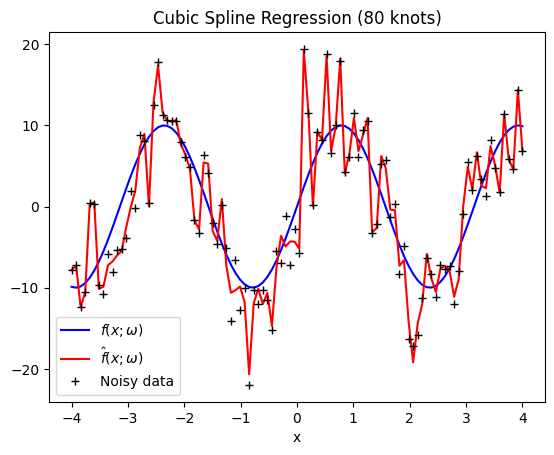

In [6]:
# working a spline regression (piecewise cubic)

# polynomial degree = 3
pfun = lambda x,degree: np.power((np.abs(x) + x)/2, degree).reshape(-1) # create {x+}^3
degree = 3
One = np.ones(x.shape)

# create basis matrix following Equation (3.12), 80 knot locations uniformly over [-4, 4]
knots = np.linspace(-3.9, 3.9, 80)
X = np.column_stack((One, x, np.power(x,2), np.power(x,3)))
for k in knots:  # append (x-kj)+^3 knot after knot to the right of X
  X = np.column_stack ((X, pfun(x-k, degree)))
  #X=np.hstack(X, pfun(x-k, degree))
w = np.linalg.solve(X.T @ X, X.T @ yn)

y_pred = X @ w

# Plot the results
plt.plot(x, y, 'b', label=r"$f(x;\omega)$")
plt.plot(x, y_pred, 'r', label=r"$\hat{f}(x;\omega)$")
plt.plot(x, yn, 'k+', label="Noisy data")
plt.xlabel('x')
plt.title('Cubic Spline Regression (80 knots)')
plt.legend()
plt.show()

# **Part 2: Perform Ridge regression to mitigate the overfitting issue**

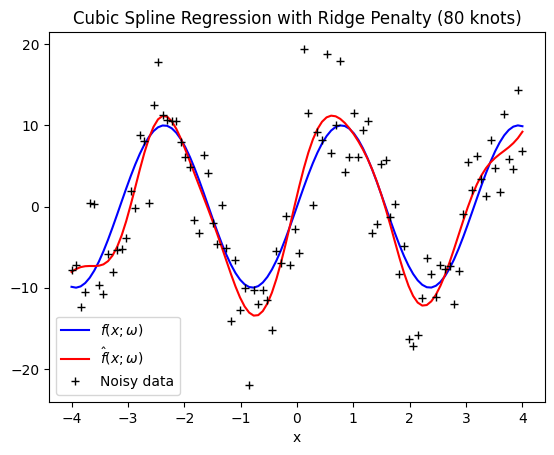

In [7]:
# Too noisy with too many knots. We do apply some shrikage approaches such as Ridge or Lasso to reduce the effects of less important knots
# Load Ridge regression model from linear_model moudle under the sklearn library
from sklearn.linear_model import Ridge

# Ridge: Minimizes the objective function: ||y - Xw||^2_2 + alpha * ||w||^2_2
# Create a ridge regression model object called clf
clf = Ridge(alpha=0.01)
clf.fit(X, yn) #Train model clf, replace w = np.linalg.solve(X.T @ X, X.T @ yn)
y_pred = clf.predict(X)# call predict method (equivalent to Y=X@w) to make prediction of regression model

# Plot the results
# Question: Compare the results to the ground truth and see if overfitting issue is mitigated.
plt.plot(x, y, 'b', label=r"$f(x;\omega)$")
plt.plot(x, y_pred, 'r', label=r"$\hat{f}(x;\omega)$")
plt.plot(x, yn, 'k+', label=r"Noisy data")
plt.xlabel('x')
plt.title('Cubic Spline Regression with Ridge Penalty (80 knots)')
plt.legend()
plt.show()


# **Part 3: Perform lasso regression to mitigate the overfitting issue**
Most of coding procedures are the same as ridge regression. However, lasso regression involves more complex algorithms for optimization since it is not a differentiable function. Therefore, extra optimization criteria should be specified, such as optimization tolerance and maximum number of iterations for the optimization.

In [ ]:
from sklearn.linear_model import Lasso

# Lasso: Minimizes the objective function: (1 / (2 * n_samples)) * ||y - Xw||^2_2 + alpha * ||w||_1
clf = Lasso(alpha=0.01, tol=1e-2, max_iter=60000)
#if you see a warning message, it means when the Lasso regression model doesn't reach an optimal solution after the specified maximum
# number of iterations. Increase iterations and increase alpha can help remove the warning.

# normalize data to Xn = (X-mu)/sigma before a model fit for a better numerical stabilization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
Xn = scaler.transform(X)

# Fit normalized data
clf.
# Make prediction based on normalize data
y_pred =

# Plot the results
# Question: Compare the results to the ground truth and see if overfitting issue is mitigated.
plt.plot(x, y, 'b', label=r"$f(x;\omega)$")
plt.plot(x, y_pred, 'r', label=r"$\hat{f}(x;\omega)$")
plt.plot(x, yn, 'k+', label=r"Noisy data")
plt.xlabel('x')
plt.title('Cubic Spline Regression with Lasso Penalty (80 knots)')
plt.legend()
plt.show()
